# Laboratorio 2.1: Factorización de Matrices

## Introducción

En este laboratorio exploraremos técnicas fundamentales de factorización matricial y su aplicación práctica en la resolución de sistemas lineales. Trabajaremos con descomposición LU y Cholesky (implementadas desde cero), y utilizaremos la descomposición QR de NumPy para comparar el comportamiento de distintos métodos ante matrices **mal condicionadas**.

## Estructura del Laboratorio
1. Descomposición LU
2. Descomposición de Cholesky
3. Resolución de sistemas lineales mal condicionados: Inversa, LU y QR


In [18]:
## Recursos necesarios
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

## Descomposición LU

La descomposición LU factoriza una matriz cuadrada A en el producto de una matriz triangular inferior L y una matriz triangular superior U, de manera que A = LU. Esta descomposición es útil para resolver sistemas lineales, calcular determinantes e inversas de matrices.

### Implementación básica de la descomposición LU

**Ejercicio L2.1.1**: Completa la siguiente implementación de la descomposición LU sin pivoteo.

In [24]:
def lu_decomposition(A):
    """
    Implementa la descomposición LU sin pivoteo para una matriz cuadrada.
    
    Args:
        A: Matriz cuadrada numpy de tamaño n x n
        
    Returns:
        L: Matriz triangular inferior con unos en la diagonal
        U: Matriz triangular superior
    """
    n = A.shape[0]
    # Verificar que la matriz sea cuadrada
    if A.shape[0] != A.shape[1]:
        raise ValueError("La matriz debe ser cuadrada")
    
    # Crear matrices L y U
    U = A.astype(float).copy()
    L = np.eye(n)
    
    # Implementar algoritmo de eliminación gaussiana
    for k in range(n - 1):
        # Verificar si el pivote es numéricamente cero dada la precisión que se usa
        if abs(U[k, k]) < 1e3 * np.finfo(U.dtype).eps:
            raise ValueError(f"Elemento pivote U[{k},{k}] es casi cero. La matriz requiere pivoteo.")
        
        for i in range(k + 1, n):
            # Guardar el multiplicador en L
            L[i, k] = U[i, k] / U[k, k]
            # Anular la entrada correspondiente en U
            U[i, k:] = U[i, k:] - L[i, k] * U[k, k:]

    return L, U

# Prueba con una matriz simple
A = np.array([[2, 1, 1], 
              [4, 3, 3], 
              [8, 7, 9]], dtype=float)

try:
    L, U = lu_decomposition(A)
    print("Matriz A:")
    print(A)
    print("\nMatriz L:")
    print(L)
    print("\nMatriz U:")
    print(U)
    print("\nVerificación L*U:")
    print(np.dot(L, U))
    print("\n¿L*U ≈ A?", np.allclose(np.dot(L, U), A))
except ValueError as e:
    print(f"Error: {e}")

Matriz A:
[[2. 1. 1.]
 [4. 3. 3.]
 [8. 7. 9.]]

Matriz L:
[[1. 0. 0.]
 [2. 1. 0.]
 [4. 3. 1.]]

Matriz U:
[[2. 1. 1.]
 [0. 1. 1.]
 [0. 0. 2.]]

Verificación L*U:
[[2. 1. 1.]
 [4. 3. 3.]
 [8. 7. 9.]]

¿L*U ≈ A? True


### Comparación con la implementación de SciPy

**Ejercicio L2.1.2**: Compara tu implementación de descomposición LU con la disponible en SciPy.  La implementación de Scipy usa la sintaxis `scipy.linalg.lu(A)`.
1. Revisa la documentación de `scipy.linalg.lu` para entender cómo funciona y los argumentos que devuelve.
2. La función `scipy.linalg.lu` devuelve tres matrices en lugar de dos. ¿Por qué?
3. Completa la función `compare_lu_implementations` para comparar tu implementación con la de SciPy.

In [8]:
def compare_lu_implementations(A):
    """
    Compara nuestra implementación de LU con la de SciPy.
    
    Args:
        A: Matriz a descomponer
    """
    try:
        # Implementación propia
        L_custom, U_custom = lu_decomposition(A)
        
        # Implementación de SciPy con pivoteo parcial
        P_scipy, L_scipy, U_scipy = la.lu(A)
        
        # Verificar la reconstrucción de SciPy
        A_reconstruida = P_scipy @ L_scipy @ U_scipy
        error_reconstruccion = np.linalg.norm(A - A_reconstruida, ord="fro")
        print("Error de reconstrucción (SciPy):", error_reconstruccion)

        # Nuestra implementación solo es comparable factor a factor si no hubo pivoteo
        uses_pivoting = not np.allclose(P_scipy, np.eye(A.shape[0]))
        print("¿SciPy necesitó pivoteo?", uses_pivoting)

        if uses_pivoting:
            print("Los factores L y U no se comparan directamente porque SciPy reordena filas.")
        else:
            print("Error entre L custom y L SciPy:", np.linalg.norm(L_custom - L_scipy))
            print("Error entre U custom y U SciPy:", np.linalg.norm(U_custom - U_scipy))
        
    except ValueError as e:
        print(f"Error: {e}")

# Prueba con la matriz del ejercicio anterior
compare_lu_implementations(A)

Error de reconstrucción (SciPy): 4.440892098500626e-16
¿SciPy necesitó pivoteo? True
Los factores L y U no se comparan directamente porque SciPy reordena filas.


### Resolución de sistemas lineales con LU

**Ejercicio L2.1.3**: Implementa la resolución de sistemas lineales utilizando la descomposición LU. Completa las funciones de sustitución hacia adelante y hacia atrás.

In [16]:
def forward_substitution(L, b):
    """
    Resuelve el sistema Ly = b mediante sustitución hacia adelante.
    Funciona para matrices triangulares inferiores con diagonal no nula.
    
    Args:
        L: Matriz triangular inferior
        b: Vector del lado derecho
        
    Returns:
        y: Solución del sistema Ly = b
    """
    n = L.shape[0]
    y = np.zeros_like(b, dtype=float)
    
    for i in range(n):
        if abs(L[i, i]) < 1e3 * np.finfo(L.dtype).eps:
            raise ValueError(f"Elemento diagonal L[{i},{i}] es casi cero.")
        y[i] = (b[i] - np.dot(L[i, :i], y[:i])) / L[i, i]
    
    return y

def backward_substitution(U, y):
    """
    Resuelve el sistema Ux = y mediante sustitución hacia atrás.
    U debe ser triangular superior.
    
    Args:
        U: Matriz triangular superior
        y: Vector del lado derecho
        
    Returns:
        x: Solución del sistema Ux = y
    """
    n = U.shape[0]
    x = np.zeros_like(y, dtype=float)
    
    for i in range(n - 1, -1, -1):
        if abs(U[i, i]) < 1e3 * np.finfo(U.dtype).eps:
            raise ValueError(f"Elemento diagonal U[{i},{i}] es casi cero.")
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]
    
    return x

def solve_linear_system_lu(A, b):
    """
    Resuelve el sistema Ax = b utilizando la descomposición LU.
    
    Args:
        A: Matriz de coeficientes
        b: Vector del lado derecho
        
    Returns:
        x: Solución del sistema
    """
    # Obtener la descomposición LU
    L, U = lu_decomposition(A)
    
    # Resolver Ly = b mediante sustitución hacia adelante
    y = forward_substitution(L, b)
    
    # Resolver Ux = y mediante sustitución hacia atrás
    x = backward_substitution(U, y)
    
    return x

# Ejemplo: Sistema lineal
A = np.array([[2, 1, 1], 
              [4, 3, 3], 
              [8, 7, 9]], dtype=float)
b = np.array([5, 16, 41], dtype=float)

# Resolver con nuestra implementación
x_custom = solve_linear_system_lu(A, b)
print("Solución con nuestra implementación:")
print(x_custom)

# Resolver con NumPy para comparar
x_numpy = np.linalg.solve(A, b)
print("\nSolución con numpy.linalg.solve:")
print(x_numpy)

print("\n¿Las soluciones son aproximadamente iguales?", np.allclose(x_custom, x_numpy))

# Verificar la solución
print("\nVerificación A*x ≈ b:")
print(np.allclose(A @ x_custom, b))

Solución con nuestra implementación:
[-0.5  4.5  1.5]

Solución con numpy.linalg.solve:
[-0.5  4.5  1.5]

¿Las soluciones son aproximadamente iguales? True

Verificación A*x ≈ b:
True


### Observando limitaciones: Caso problemático

**Ejercicio L2.1.4**: Experimenta con un caso donde la descomposición LU sin pivoteo falla o produce resultados numéricamente inestables.

In [6]:
def test_lu_stability():
    """
    Prueba un caso donde la descomposición LU sin pivoteo presenta problemas.
    """
    # Matriz que requerirá pivoteo
    A_problematic = np.array([[0, 1], 
                              [1, 1]], dtype=float)
    
    print("Matriz problemática:")
    print(A_problematic)
    
    # Intentar descomposición LU sin pivoteo
    try:
        L, U = lu_decomposition(A_problematic)
        print("L:")
        print(L)
        print("U:")
        print(U)
        print("Verificación L*U:")
        print(np.dot(L, U))
        print("¿L*U ≈ A?", np.allclose(np.dot(L, U), A_problematic))
    except ValueError as e:
        print(f"Error con nuestra implementación: {e}")
    
    # Comparar con SciPy (que usa pivoteo)
    print("\nDescomposición LU con SciPy (incluye pivoteo):")
    P, L, U = la.lu(A_problematic)
    print("P:\n", P)
    print("L:\n", L)
    print("U:\n", U)
    print("Reconstrucción de A:")
    A_reconstruida = P @ L @ U
    print(A_reconstruida)
    print("¿A_reconstruida ≈ A?", np.allclose(A_reconstruida, A_problematic))

test_lu_stability()

Matriz problemática:
[[0. 1.]
 [1. 1.]]
Error con nuestra implementación: Elemento pivote U[0,0] es casi cero. La matriz requiere pivoteo.

Descomposición LU con SciPy (incluye pivoteo):
P:
 [[0. 1.]
 [1. 0.]]
L:
 [[1. 0.]
 [0. 1.]]
U:
 [[1. 1.]
 [0. 1.]]
Reconstrucción de A:
[[0. 1.]
 [1. 1.]]
¿A_reconstruida ≈ A? True


**Ejercicio L2.1.5**: Crea una función que calcule el determinante de una matriz utilizando la descomposición LU. Compara el resultado con `np.linalg.det`.

In [7]:
def determinant_from_lu(A):
    """Calcula el determinante usando la diagonal de U."""
    _, U = lu_decomposition(A)
    return np.prod(np.diag(U))

A_det = np.array([[3, 1, 2],
                  [2, 4, 1],
                  [1, 2, 5]], dtype=float)

det_custom = determinant_from_lu(A_det)
det_numpy = np.linalg.det(A_det)

print("Determinante con LU:", det_custom)
print("Determinante con np.linalg.det:", det_numpy)
print("¿Coinciden aproximadamente?", np.allclose(det_custom, det_numpy))

Determinante con LU: 45.0
Determinante con np.linalg.det: 45.000000000000014
¿Coinciden aproximadamente? True


## Descomposición de Cholesky

La descomposición de Cholesky es una factorización de una matriz simétrica definida positiva en el producto de una matriz triangular inferior y su transpuesta: A = LL^T. Es aproximadamente dos veces más eficiente que la descomposición LU para este tipo de matrices.

### Implementación básica de la descomposición de Cholesky

**Ejercicio L2.1.6**: Completa la implementación de la descomposición de Cholesky.

In [9]:
def is_symmetric(A, tol=1e-8):
    """
    Verifica si una matriz es simétrica.
    
    Args:
        A: Matriz a verificar
        tol: Tolerancia para la comparación
        
    Returns:
        bool: True si la matriz es simétrica, False en caso contrario
    """
    result = np.allclose(A, A.T, atol=tol)
    return result

def is_positive_definite(A):
    """
    Verifica si una matriz es definida positiva comprobando sus eigenvalores.
    
    Args:
        A: Matriz a verificar
        
    Returns:
        bool: True si la matriz es definida positiva, False en caso contrario
    """

    # SUGERENCIA: Una matriz es definida positiva si todos sus valores propios son positivos
    eigenvalues = np.linalg.eigvalsh(A)
    result = np.all(eigenvalues > 1e-12)
    return result

def cholesky_decomposition(A):
    """
    Implementa la descomposición de Cholesky para una matriz simétrica definida positiva.
    
    Args:
        A: Matriz simétrica definida positiva de tamaño n x n
        
    Returns:
        L: Matriz triangular inferior tal que A = L*L^T
    """
    n = A.shape[0]
    
    # Verificar que la matriz sea cuadrada
    if A.shape[0] != A.shape[1]:
        raise ValueError("La matriz debe ser cuadrada")
    
    # Verificar que la matriz sea simétrica
    if not is_symmetric(A):
        raise ValueError("La matriz debe ser simétrica")
    
    # Verificar que la matriz sea definida positiva
    if not is_positive_definite(A):
        raise ValueError("La matriz debe ser definida positiva")
    
    # Crear matriz L (inicialmente con ceros)
    L = np.zeros_like(A, dtype=float)
    
    # Implementar algoritmo de Cholesky
    for i in range(n):
        for j in range(i + 1):
            subtotal = np.dot(L[i, :j], L[j, :j])
            if i == j:
                value = A[i, i] - subtotal
                if value <= 0:
                    raise ValueError("La matriz no es definida positiva")
                L[i, j] = np.sqrt(value)
            else:
                L[i, j] = (A[i, j] - subtotal) / L[j, j]
    
    return L

# Prueba con una matriz simétrica definida positiva
A = np.array([[4, 12, -16],
              [12, 37, -43],
              [-16, -43, 98]], dtype=float)

try:
    L = cholesky_decomposition(A)
    print("Matriz A:")
    print(A)
    print("\nMatriz L (Cholesky):")
    print(L)
    print("\nVerificación L*L^T:")
    print(L @ L.T)
    print("\n¿L*L^T ≈ A?", np.allclose(L @ L.T, A))
except ValueError as e:
    print(f"Error: {e}")

Matriz A:
[[  4.  12. -16.]
 [ 12.  37. -43.]
 [-16. -43.  98.]]

Matriz L (Cholesky):
[[ 2.  0.  0.]
 [ 6.  1.  0.]
 [-8.  5.  3.]]

Verificación L*L^T:
[[  4.  12. -16.]
 [ 12.  37. -43.]
 [-16. -43.  98.]]

¿L*L^T ≈ A? True


### Comparación con la implementación de NumPy

**Ejercicio L2.1.7**: Compara tu implementación de la descomposición de Cholesky con la disponible en NumPy.
1. Busca la función `numpy.linalg.cholesky` y revisa su documentación.
2. Completa la función `compare_cholesky_implementations` para comparar tu implementación con la de NumPy.

In [10]:
def compare_cholesky_implementations(A):
    """
    Compara nuestra implementación de Cholesky con la de NumPy.
    
    Args:
        A: Matriz a descomponer
    """
    try:
        # Nuestra implementación
        L_custom = cholesky_decomposition(A)
        
        # Implementación de NumPy
        L_numpy = np.linalg.cholesky(A)
        
        # Comparar resultados mediante norma Frobenius de la diferencia entre matrices
        diferencia_resultados = np.linalg.norm(L_custom - L_numpy, ord="fro")
        print("Error entre L custom y L NumPy:", diferencia_resultados)
        
        # Verificar que ambas factorizaciones reconstruyen A
        error_propio = np.linalg.norm(A - L_custom @ L_custom.T, ord="fro")
        error_numpy = np.linalg.norm(A - L_numpy @ L_numpy.T, ord="fro")
        print("Error de reconstrucción (custom):", error_propio)
        print("Error de reconstrucción (NumPy):", error_numpy)
        
    except ValueError as e:
        print(f"Error: {e}")

# Prueba con la matriz del ejercicio anterior
compare_cholesky_implementations(A)

Error entre L custom y L NumPy: 0.0
Error de reconstrucción (custom): 0.0
Error de reconstrucción (NumPy): 0.0


### Resolución de sistemas lineales con Cholesky

**Ejercicio L2.1.8**: Implementa la resolución de sistemas lineales utilizando la descomposición de Cholesky.

In [17]:
def solve_linear_system_cholesky(A, b):
    """
    Resuelve el sistema Ax = b utilizando la descomposición de Cholesky.
    
    Args:
        A: Matriz de coeficientes (simétrica definida positiva)
        b: Vector del lado derecho
        
    Returns:
        x: Solución del sistema
    """
    # Resolver primero Ly = b y luego L^T x = y
    L = cholesky_decomposition(A)
    y = forward_substitution(L, b)
    x = backward_substitution(L.T, y)
    return x

# Ejemplo: Sistema lineal con matriz simétrica definida positiva
A = np.array([[4, 1, 1],
              [1, 3, 1],
              [1, 1, 5]], dtype=float)
b = np.array([6, 5, 7], dtype=float)

# Resolver con nuestra implementación
x_custom = solve_linear_system_cholesky(A, b)
print("Solución con nuestra implementación:")
print(x_custom)

# Resolver con NumPy para comparar
x_numpy = np.linalg.solve(A, b)
print("\nSolución con numpy.linalg.solve:")
print(x_numpy)

print("\n¿Las soluciones son aproximadamente iguales?", np.allclose(x_custom, x_numpy))

# Verificar la solución propia
print("\nVerificación A*x ≈ b:")
print(np.allclose(A @ x_custom, b))

Solución con nuestra implementación:
[1. 1. 1.]

Solución con numpy.linalg.solve:
[1. 1. 1.]

¿Las soluciones son aproximadamente iguales? True

Verificación A*x ≈ b:
True


### Generación de datos con una matriz de correlación específica
**Ejercicio L2.1.9**: Genera datos aleatorios con una matriz de correlación específica utilizando la descomposición de Cholesky.

In [12]:
def generate_correlated_data(correlation_matrix, n_samples):
    """
    Genera datos aleatorios con una matriz de correlación específica.
    
    Args:
        correlation_matrix: Matriz de correlación deseada
        n_samples: Número de muestras a generar
        
    Returns:
        data: Datos generados con la matriz de correlación especificada
    """
    # Verificar que la matriz sea simétrica y definida positiva
    if not is_symmetric(correlation_matrix) or not is_positive_definite(correlation_matrix):
        raise ValueError("La matriz debe ser simétrica y definida positiva")
    
    # Obtener la descomposición de Cholesky
    L = cholesky_decomposition(correlation_matrix)
    
    # Generar datos aleatorios independientes
    # NOTA: randn genera datos con covarianza identidad.
    independent_data = np.random.randn(n_samples, correlation_matrix.shape[0])
    
    # Generar datos correlacionados
    correlated_data = independent_data @ L.T
    
    return correlated_data

# Ejemplo de uso
np.random.seed(42)
correlation_matrix = np.array([[1, 0.8], 
                                 [0.8, 1]], dtype=float)
n_samples = 1000
data = generate_correlated_data(correlation_matrix, n_samples)

# Calcular media y covarianza de los datos generados
mean_data = np.mean(data, axis=0)
cov_data = np.cov(data, rowvar=False)
print("Media de los datos generados:", mean_data)
print("Covarianza de los datos generados:", cov_data)

# Comparar covarianza empírica con la matriz objetivo
error_cov = np.linalg.norm(cov_data - correlation_matrix, ord="fro")
print("Error de covarianza empírica:", error_cov)

Media de los datos generados: [0.03318614 0.0607382 ]
Covarianza de los datos generados: [[0.924681   0.74125806]
 [0.74125806 0.9650683 ]]
Error de covarianza empírica: 0.11744959127213005


## Resolución de Sistemas Lineales Mal Condicionados

El **número de condición** $κ(A) = ‖A‖ \cdot ‖A^{-1}‖$ mide cuánto se amplifica el error en la solución ante pequeñas perturbaiones en los datos de entrada. Cuando κ(A) ≫ 1, la matriz está **mal condicionada** y los métodos numéricos pueden introducir errores importantes.

Distintos algoritmos explotan estructuras diferentes de la matriz y propagan los errores de redondeo de formas distintas. En esta sección compararás tres estrategias clásicas:

| Método | Idea central | Complejidad |
|--------|-------------|-------------|
| Inversa explícita | $x = A^{-1}b$ | $O(n^3)$ + propenso a error |
| LU con pivoteo | PA = LU; resolver dos sistemas triangulares | $O(n^3)$ |
| QR | $A = QR$; resolver $Rx = Qᵀb$ | $O(n^3)$, mejor estabilidad |

### La Matriz de Hilbert

Utilizaremos la **matriz de Hilbert** $H ∈ ℝⁿˣⁿ$ con $Hᵢⱼ = 1/(i+j−1)$ (índices 1-based),
famosa por su extremo mal condicionamiento: $κ(Hₙ)$ crece exponencialmente con n.

In [13]:
def hilbert_matrix(n):
    """
    Genera la matriz de Hilbert de tamaño n×n.
    H[i,j] = 1 / (i + j + 1)  (índices 0-based, equivale a H_{i+1,j+1}=1/(i+j+1))
    
    Args:
        n: Tamaño de la matriz
    Returns:
        H: Matriz de Hilbert n×n
    """
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            H[i, j] = 1.0 / (i + j + 1)
    return H

# Configurar el problema de prueba principal
n = 8
H = hilbert_matrix(n)
x_true = np.ones(n)      # Solución exacta conocida
b = H @ x_true           # Vector del lado derecho

print(f"Tamaño de la matriz: {n}×{n}")
print(f"Número de condición κ(H): {np.linalg.cond(H):.4e}")
print(f"Primeros elementos de H:")
print(H[:3, :4].round(4))

Tamaño de la matriz: 8×8
Número de condición κ(H): 1.5258e+10
Primeros elementos de H:
[[1.     0.5    0.3333 0.25  ]
 [0.5    0.3333 0.25   0.2   ]
 [0.3333 0.25   0.2    0.1667]]


### Comparación de métodos de resolución

**Ejercicio L2.1.10**: Implementa las tres funciones de resolución y compara su precisión sobre el sistema Hx = b con x_true = [1, 1, …, 1].

Para el **método QR**: si A = QR (con Q ortogonal y R triangular superior), entonces:
$$Ax = b \implies QRx = b \implies Rx = Q^\top b$$
El sistema triangular Rx = Qᵀb se resuelve eficientemente con sustitución hacia atrás.


In [14]:
def solve_with_inverse(A, b):
    """
    Resuelve Ax = b calculando explícitamente la inversa de A.
    
    Returns:
        x: solución aproximada
    """
    x = np.linalg.inv(A) @ b
    return x


def solve_with_lu(A, b):
    """
    Resuelve Ax = b mediante descomposición LU con pivoteo (SciPy).
    
    Returns:
        x: solución aproximada
    """
    lu, piv = la.lu_factor(A)
    x = la.lu_solve((lu, piv), b)
    return x


def solve_with_qr(A, b):
    """
    Resuelve Ax = b mediante descomposición QR (NumPy).
    Pasos: 1) A = QR con np.linalg.qr(A)
           2) y = Qᵀ b
           3) x = R⁻¹ y  (via np.linalg.solve(R, y))
    
    Returns:
        x: solución aproximada
    """
    Q, R = np.linalg.qr(A)
    y = Q.T @ b
    x = np.linalg.solve(R, y)
    return x


# ── Resolver con los tres métodos ────────────────────────────────────────────
x_inv = solve_with_inverse(H, b)
x_lu  = solve_with_lu(H, b)
x_qr  = solve_with_qr(H, b)

# ── Comparar errores relativos ────────────────────────────────────────────────
def relative_error(x_approx, x_exact):
    """Error relativo en norma 2."""
    return np.linalg.norm(x_approx - x_exact) / np.linalg.norm(x_exact)

err_inv = relative_error(x_inv, x_true)
err_lu  = relative_error(x_lu,  x_true)
err_qr  = relative_error(x_qr,  x_true)

print(f"{'Método':<25} {'Error relativo':>20}")
print("-" * 47)
print(f"{'Inversa explícita':<25} {err_inv:>20.4e}")
print(f"{'LU (con pivoteo)':<25} {err_lu:>20.4e}")
print(f"{'QR':<25} {err_qr:>20.4e}")
print()
print(f"κ(H_{n}) = {np.linalg.cond(H):.2e}  →  precisión de máquina ε ≈ {np.finfo(float).eps:.2e}")
print(f"Error esperado (orden de magnitud): κ·ε ≈ {np.linalg.cond(H)*np.finfo(float).eps:.2e}")

Método                          Error relativo
-----------------------------------------------
Inversa explícita                   9.3476e-07
LU (con pivoteo)                    6.1241e-08
QR                                  1.1911e-07

κ(H_8) = 1.53e+10  →  precisión de máquina ε ≈ 2.22e-16
Error esperado (orden de magnitud): κ·ε ≈ 3.39e-06


**Ejercicio L2.1.11**: Analiza cómo evoluciona el error relativo de cada método al aumentar el tamaño n de la matriz de Hilbert. Completa el bucle y genera la gráfica comparativa.


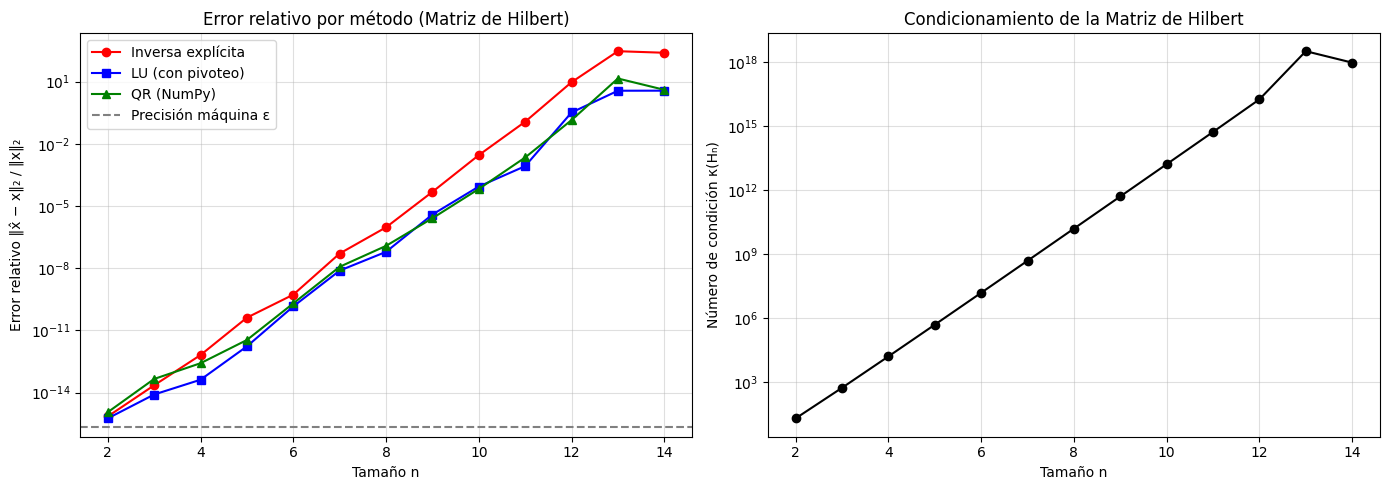

Conclusión:
A medida que n crece, κ(Hₙ) aumenta muy rápido y los errores relativos también. La inversa explícita suele ser la estrategia menos estable; QR tiende a ser la más robusta y LU con pivoteo queda en un punto intermedio, aunque también se degrada cuando el condicionamiento es extremo.


In [15]:
sizes = list(range(2, 15))
errors_inv, errors_lu, errors_qr, cond_nums = [], [], [], []

for n in sizes:
    H_n = hilbert_matrix(n)
    x_t = np.ones(n)
    b_n = H_n @ x_t
    cond_nums.append(np.linalg.cond(H_n))

    # Medir error relativo de cada método; si falla, guardar NaN.
    try:
        errors_inv.append(relative_error(solve_with_inverse(H_n, b_n), x_t))
    except np.linalg.LinAlgError:
        errors_inv.append(np.nan)

    try:
        errors_lu.append(relative_error(solve_with_lu(H_n, b_n), x_t))
    except np.linalg.LinAlgError:
        errors_lu.append(np.nan)

    try:
        errors_qr.append(relative_error(solve_with_qr(H_n, b_n), x_t))
    except np.linalg.LinAlgError:
        errors_qr.append(np.nan)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(sizes, errors_inv, 'o-', color='red',   label='Inversa explícita')
ax.semilogy(sizes, errors_lu,  's-', color='blue',  label='LU (con pivoteo)')
ax.semilogy(sizes, errors_qr,  '^-', color='green', label='QR (NumPy)')
ax.axhline(np.finfo(float).eps, color='gray', ls='--', label='Precisión máquina ε')
ax.set_xlabel('Tamaño n')
ax.set_ylabel('Error relativo ‖x̂ − x‖₂ / ‖x‖₂')
ax.set_title('Error relativo por método (Matriz de Hilbert)')
ax.legend()
ax.grid(True, which='both', alpha=0.4)

ax = axes[1]
ax.semilogy(sizes, cond_nums, 'k-o')
ax.set_xlabel('Tamaño n')
ax.set_ylabel('Número de condición κ(Hₙ)')
ax.set_title('Condicionamiento de la Matriz de Hilbert')
ax.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

print("Conclusión:")
print(
    "A medida que n crece, κ(Hₙ) aumenta muy rápido y los errores relativos también. "
    "La inversa explícita suele ser la estrategia menos estable; QR tiende a ser la más robusta "
    "y LU con pivoteo queda en un punto intermedio, aunque también se degrada cuando el condicionamiento es extremo."
)

## Ejercicios adicionales (OPCIONAL)

**L2.1.12**: Compara también la descomposición LU **sin pivoteo** (tu implementación del Ejercicio L2.1.1) con SciPy en el experimento anterior. ¿Qué diferencias observas? ¿Por qué el pivoteo mejora la estabilidad?

**L2.1.13**: Implementa una función que calcule la inversa de una matriz utilizando la descomposición LU (sin llamar a `np.linalg.inv`).

**L2.1.14**: El **número de condición** puede estimarse eficientemente sin calcular A⁻¹ explícitamente. Investiga el método de estimación de condición de Hager-Higham e impleméntalo.

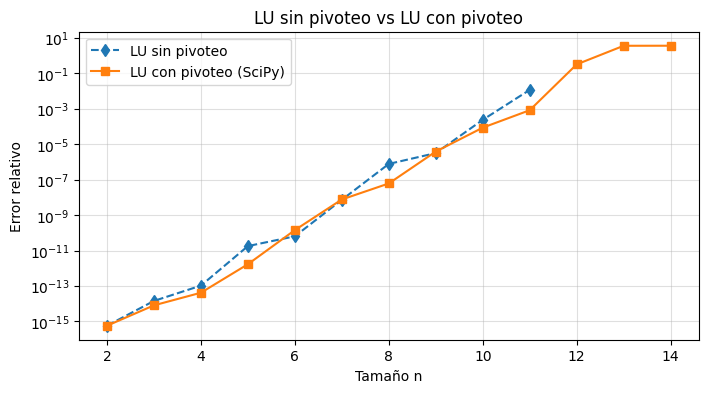

L2.1.12:
LU sin pivoteo se vuelve menos estable y puede fallar cuando aparecen pivotes muy pequeños. El pivoteo mejora la estabilidad porque reordena filas para evitar divisiones por valores cercanos a cero.

L2.1.13:
Inversa con LU:
 [[ 0.30434783 -0.06521739 -0.10869565]
 [ 0.04347826  0.34782609 -0.08695652]
 [-0.13043478 -0.04347826  0.26086957]]
Error frente a np.linalg.inv: 0.0
¿A @ A^{-1} ≈ I? True

L2.1.14:
Estimación Hager-Higham de cond_1(H8): 33872792384.490704
Valor de referencia con np.linalg.cond(H8, 1): 33872792384.49069
Error relativo de la estimación: 4.504733146679259e-16


In [20]:
# L2.1.12 ─ Comparar LU sin pivoteo vs LU con pivoteo

def solve_with_lu_no_pivot(A, b):
    """Resuelve Ax=b usando nuestra LU sin pivoteo."""
    return solve_linear_system_lu(A, b)

errors_lu_no_pivot = []

for n in sizes:
    H_n = hilbert_matrix(n)
    x_t = np.ones(n)
    b_n = H_n @ x_t

    try:
        x_no_pivot = solve_with_lu_no_pivot(H_n, b_n)
        errors_lu_no_pivot.append(relative_error(x_no_pivot, x_t))
    except ValueError:
        errors_lu_no_pivot.append(np.nan)

plt.figure(figsize=(8, 4))
plt.semilogy(sizes, errors_lu_no_pivot, 'd--', label='LU sin pivoteo')
plt.semilogy(sizes, errors_lu, 's-', label='LU con pivoteo (SciPy)')
plt.xlabel('Tamaño n')
plt.ylabel('Error relativo')
plt.title('LU sin pivoteo vs LU con pivoteo')
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()

print('L2.1.12:')
print(
    'LU sin pivoteo se vuelve menos estable y puede fallar cuando aparecen pivotes muy pequeños. '
    'El pivoteo mejora la estabilidad porque reordena filas para evitar divisiones por valores cercanos a cero.'
)


# L2.1.13 ─ Inversa usando LU sin np.linalg.inv

def inverse_from_lu(A):
    """Calcula A^{-1} resolviendo A x_i = e_i para cada columna."""
    n = A.shape[0]
    L, U = lu_decomposition(A)
    inverse = np.zeros((n, n), dtype=float)

    for i in range(n):
        e_i = np.zeros(n)
        e_i[i] = 1.0
        y = forward_substitution(L, e_i)
        inverse[:, i] = backward_substitution(U, y)

    return inverse

A_inv_test = np.array([[4, 1, 2],
                       [0, 3, 1],
                       [2, 1, 5]], dtype=float)
A_inv_custom = inverse_from_lu(A_inv_test)
A_inv_numpy = np.linalg.inv(A_inv_test)

print('\nL2.1.13:')
print('Inversa con LU:\n', A_inv_custom)
print('Error frente a np.linalg.inv:', np.linalg.norm(A_inv_custom - A_inv_numpy, ord='fro'))
print('¿A @ A^{-1} ≈ I?', np.allclose(A_inv_test @ A_inv_custom, np.eye(A_inv_test.shape[0])))


# L2.1.14 ─ Estimación del número de condición con Hager-Higham

def hager_higham_inverse_norm_estimate(A, max_iter=20):
    """Estima ||A^{-1}||_1 sin calcular la inversa explícitamente."""
    n = A.shape[0]
    x = np.full(n, 1 / n)
    lu_factorization = la.lu_factor(A)
    est = 0.0

    for _ in range(max_iter):
        y = la.lu_solve(lu_factorization, x)
        est_new = np.linalg.norm(y, 1)
        if est_new <= est:
            break

        est = est_new
        s = np.sign(y)
        s[s == 0] = 1.0
        z = la.lu_solve(lu_factorization, s, trans=1)
        j = np.argmax(np.abs(z))
        x_new = np.zeros(n)
        x_new[j] = 1.0

        if np.allclose(x, x_new):
            break
        x = x_new

    return est


def hager_higham_condition_estimate(A, max_iter=20):
    """Estima cond_1(A) = ||A||_1 * ||A^{-1}||_1."""
    return np.linalg.norm(A, 1) * hager_higham_inverse_norm_estimate(A, max_iter=max_iter)

H8 = hilbert_matrix(8)
cond_estimated = hager_higham_condition_estimate(H8)
cond_exact = np.linalg.cond(H8, p=1)

print('\nL2.1.14:')
print('Estimación Hager-Higham de cond_1(H8):', cond_estimated)
print('Valor de referencia con np.linalg.cond(H8, 1):', cond_exact)
print('Error relativo de la estimación:', abs(cond_estimated - cond_exact) / cond_exact)